In [7]:
# Import Python Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import plotly.express as px

In [9]:
# Load Dataset

df = pd.read_csv(r"C:\Users\HP\Desktop\MY DATA SCIENCE\Quick commerce\quick_commerce_data_raw.csv")

In [10]:
df

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702.33750,19.182,11.97,12.0,Dairy,Wallet,2.1,1,3.2
1,1000002,Flipkart Minutes,Amritsar,56,1007.30000,19.644,12.74,10.0,Snacks,Cash on Delivery,2.3,0,3.2
2,1000003,Flipkart Minutes,Mumbai,18,1211.66000,16.910,4.85,NaN,Personal Care,Cash on Delivery,3.3,0,3.8
3,1000004,Swiggy Instamart,Delhi,23,1179.05925,5.864,6.44,2.0,Dairy,Credit Card,5.0,1,5.0
4,1000005,Dunzo,Mumbai,44,586.02550,12.470,2.45,13.0,Household,Wallet,3.7,0,4.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,1999996,Big Basket,Mumbai,48,72.33000,17.806,3.01,19.0,Fruits & Vegetables,Wallet,4.2,0,2.8
999996,1999997,Swiggy Instamart,Mumbai,33,1509.66300,18.306,10.51,9.0,Beverages,Debit Card,4.1,1,3.5
999997,1999998,Jio Mart,Noida,29,637.32300,17.590,2.65,6.0,Groceries,Cash on Delivery,3.4,0,4.6
999998,1999999,Dunzo,Pune,42,1103.12100,12.656,7.76,12.0,Snacks,Wallet,4.0,1,4.5


In [11]:
# Dataset Structure

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 13 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   Order_ID                 1000000 non-null  int64  
 1   Company                  1000000 non-null  object 
 2   City                     948000 non-null   object 
 3   Customer_Age             1000000 non-null  int64  
 4   Order_Value              1000000 non-null  float64
 5   Delivery_Time_Min        1000000 non-null  float64
 6   Distance_Km              1000000 non-null  float64
 7   Items_Count              965000 non-null   float64
 8   Product_Category         1000000 non-null  object 
 9   Payment_Method           1000000 non-null  object 
 10  Customer_Rating          953000 non-null   float64
 11  Discount_Applied         1000000 non-null  int64  
 12  Delivery_Partner_Rating  895863 non-null   float64
dtypes: float64(6), int64(3), object(4)
memory u

In [12]:
df[df.isna().all(axis=1)]

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating


Remove Rows having Null Values

In [13]:
# Drop those rows that have missing values in 'City' column

df = df.dropna(subset = ['City'])

In [14]:
df

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702.33750,19.182,11.97,12.0,Dairy,Wallet,2.1,1,3.2
1,1000002,Flipkart Minutes,Amritsar,56,1007.30000,19.644,12.74,10.0,Snacks,Cash on Delivery,2.3,0,3.2
2,1000003,Flipkart Minutes,Mumbai,18,1211.66000,16.910,4.85,NaN,Personal Care,Cash on Delivery,3.3,0,3.8
3,1000004,Swiggy Instamart,Delhi,23,1179.05925,5.864,6.44,2.0,Dairy,Credit Card,5.0,1,5.0
4,1000005,Dunzo,Mumbai,44,586.02550,12.470,2.45,13.0,Household,Wallet,3.7,0,4.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,1999996,Big Basket,Mumbai,48,72.33000,17.806,3.01,19.0,Fruits & Vegetables,Wallet,4.2,0,2.8
999996,1999997,Swiggy Instamart,Mumbai,33,1509.66300,18.306,10.51,9.0,Beverages,Debit Card,4.1,1,3.5
999997,1999998,Jio Mart,Noida,29,637.32300,17.590,2.65,6.0,Groceries,Cash on Delivery,3.4,0,4.6
999998,1999999,Dunzo,Pune,42,1103.12100,12.656,7.76,12.0,Snacks,Wallet,4.0,1,4.5


In [13]:
df.shape

(948000, 13)

In [15]:
# Check Missing Values

df.isna().sum()

Order_ID                       0
Company                        0
City                           0
Customer_Age                   0
Order_Value                    0
Delivery_Time_Min              0
Distance_Km                    0
Items_Count                33228
Product_Category               0
Payment_Method                 0
Customer_Rating            44575
Discount_Applied               0
Delivery_Partner_Rating    98694
dtype: int64

In [16]:
x = df['Items_Count'].mode()

In [17]:
x

0    19.0
Name: Items_Count, dtype: float64

In [18]:
type(x)

pandas.core.series.Series

In [19]:
# Fill Missing Values with Mode

df['Items_Count'].fillna(x[0], inplace = True)

C:\Users\HP\AppData\Local\Temp\ipykernel_14332\4096315403.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Items_Count'].fillna(x[0], inplace = True)
C:\Users\HP\AppData\Local\Temp\ipykernel_14332\4096315403.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Items_Count'].fillna(x[0], inplace = True)


In [20]:
# Check Missing Values

df.isna().sum()

Order_ID                       0
Company                        0
City                           0
Customer_Age                   0
Order_Value                    0
Delivery_Time_Min              0
Distance_Km                    0
Items_Count                    0
Product_Category               0
Payment_Method                 0
Customer_Rating            44575
Discount_Applied               0
Delivery_Partner_Rating    98694
dtype: int64

Fill Null Values with Group-wise Mean/Median

In [21]:
# Use group-wise mean imputation

df['Customer_Rating'] = df.groupby("Company")["Customer_Rating"].transform(lambda x:x.fillna(x.mean()))

C:\Users\HP\AppData\Local\Temp\ipykernel_14332\3551781152.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Customer_Rating'] = df.groupby("Company")["Customer_Rating"].transform(lambda x:x.fillna(x.mean()))


In [22]:
# Check Missing Values

df.isna().sum()

Order_ID                       0
Company                        0
City                           0
Customer_Age                   0
Order_Value                    0
Delivery_Time_Min              0
Distance_Km                    0
Items_Count                    0
Product_Category               0
Payment_Method                 0
Customer_Rating                0
Discount_Applied               0
Delivery_Partner_Rating    98694
dtype: int64

In [23]:
df['Delivery_Partner_Rating'] = df.groupby('Delivery_Time_Min')['Delivery_Partner_Rating'].transform(lambda y:y.fillna(y.mean()))

C:\Users\HP\AppData\Local\Temp\ipykernel_14332\382663652.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Delivery_Partner_Rating'] = df.groupby('Delivery_Time_Min')['Delivery_Partner_Rating'].transform(lambda y:y.fillna(y.mean()))


In [24]:
df['Delivery_Partner_Rating'] = df['Delivery_Partner_Rating'].fillna( df['Delivery_Partner_Rating'].mean() )

C:\Users\HP\AppData\Local\Temp\ipykernel_14332\858619857.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Delivery_Partner_Rating'] = df['Delivery_Partner_Rating'].fillna( df['Delivery_Partner_Rating'].mean() )


In [25]:
# Check Missing Values

df.isna().sum()

Order_ID                   0
Company                    0
City                       0
Customer_Age               0
Order_Value                0
Delivery_Time_Min          0
Distance_Km                0
Items_Count                0
Product_Category           0
Payment_Method             0
Customer_Rating            0
Discount_Applied           0
Delivery_Partner_Rating    0
dtype: int64

In [26]:
# Dataset structure

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 948000 entries, 0 to 999999
Data columns (total 13 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Order_ID                 948000 non-null  int64  
 1   Company                  948000 non-null  object 
 2   City                     948000 non-null  object 
 3   Customer_Age             948000 non-null  int64  
 4   Order_Value              948000 non-null  float64
 5   Delivery_Time_Min        948000 non-null  float64
 6   Distance_Km              948000 non-null  float64
 7   Items_Count              948000 non-null  float64
 8   Product_Category         948000 non-null  object 
 9   Payment_Method           948000 non-null  object 
 10  Customer_Rating          948000 non-null  float64
 11  Discount_Applied         948000 non-null  int64  
 12  Delivery_Partner_Rating  948000 non-null  float64
dtypes: float64(6), int64(3), object(4)
memory usage: 101.3+ MB


Remove Outliers

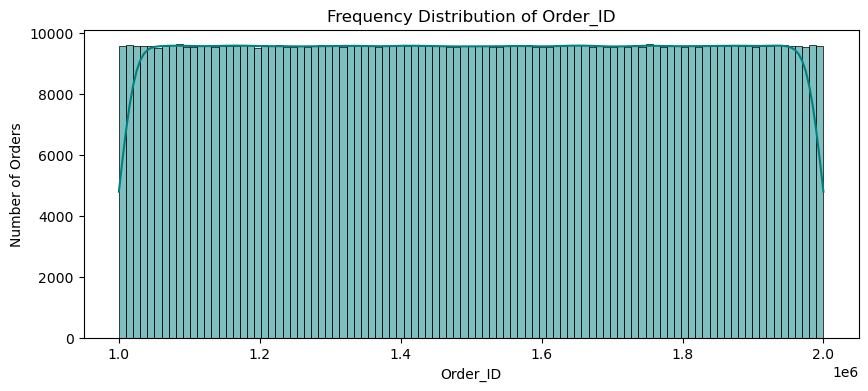

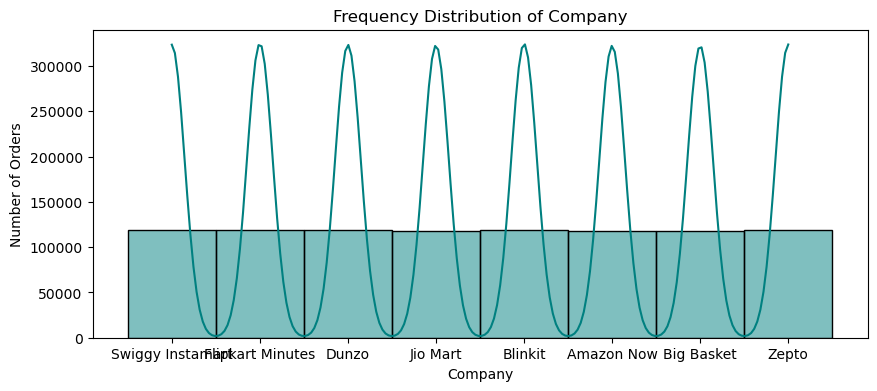

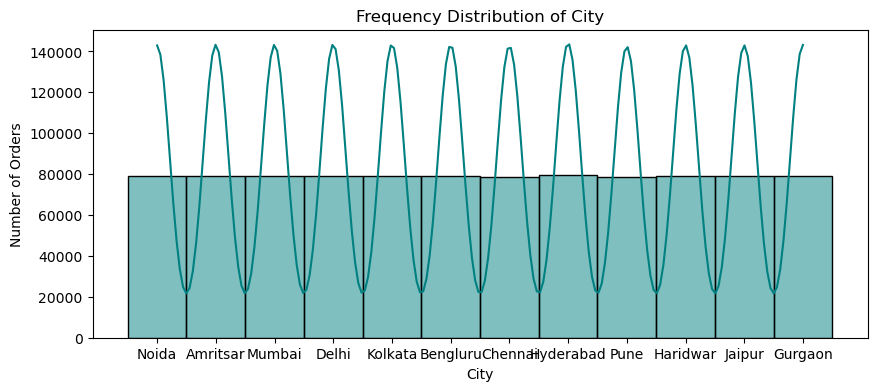

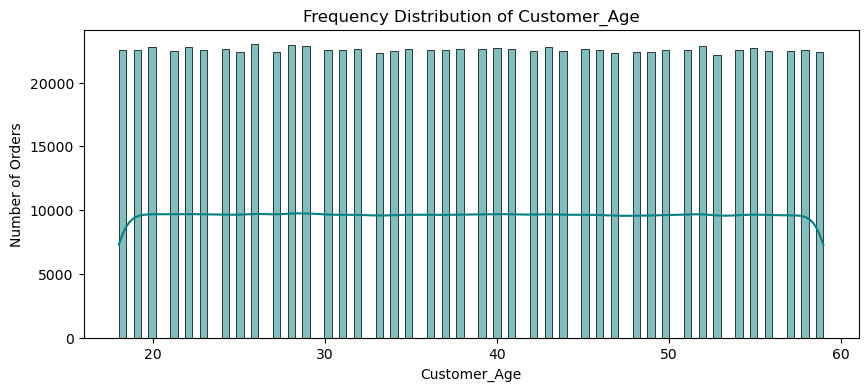

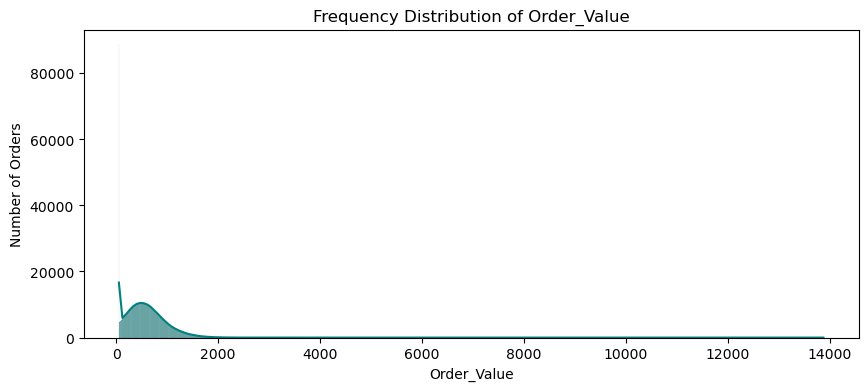

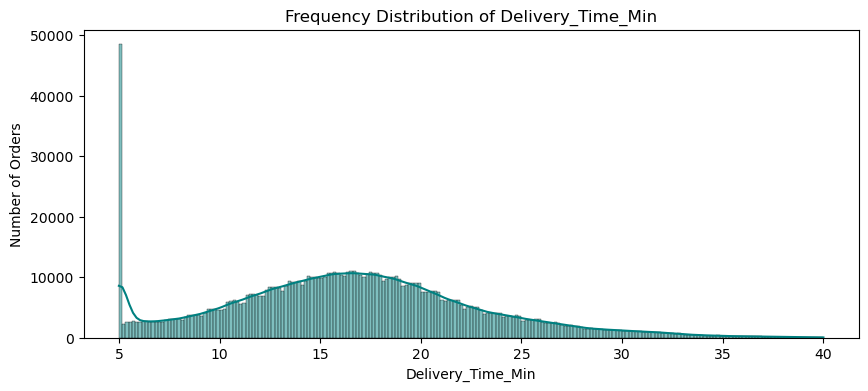

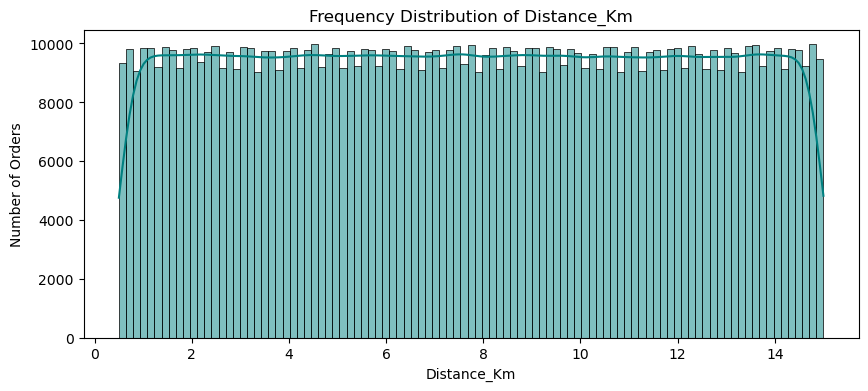

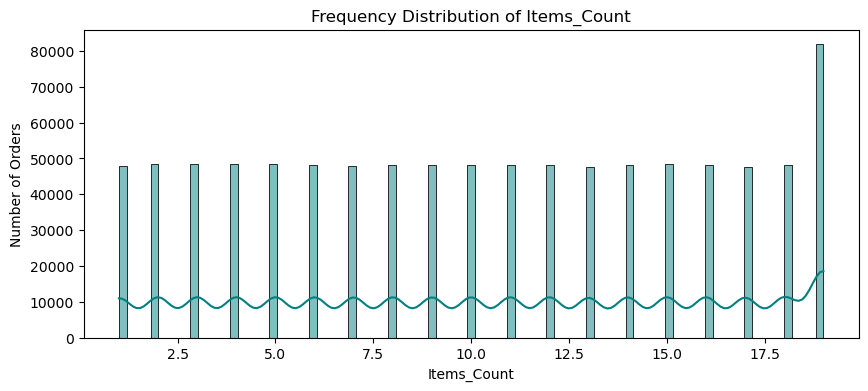

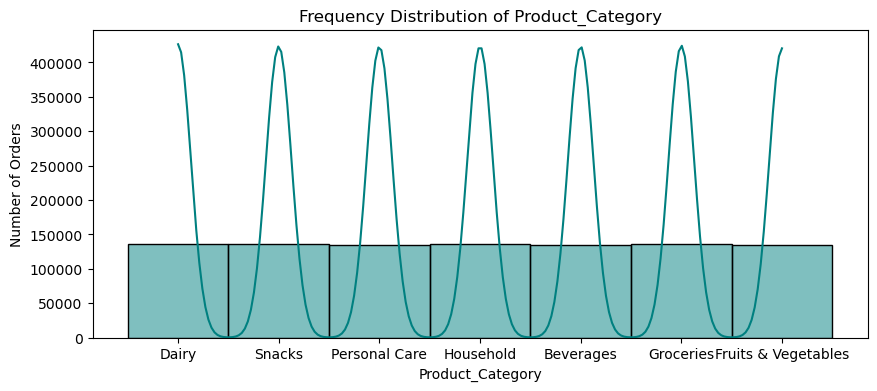

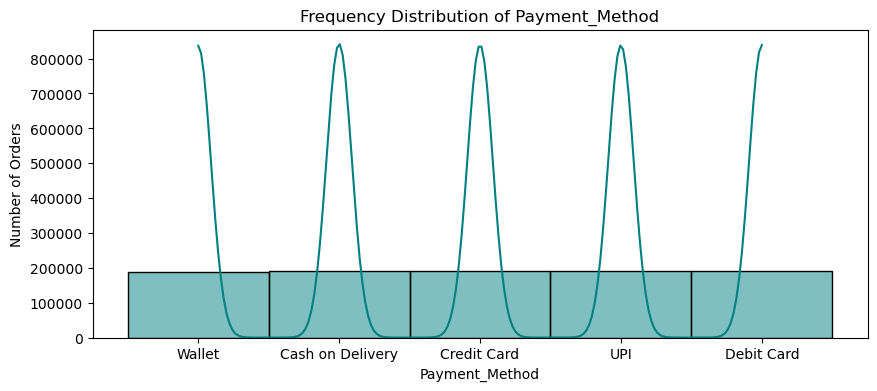

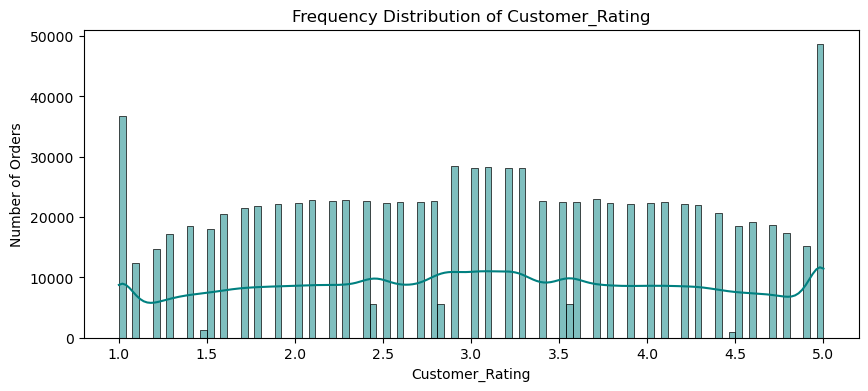

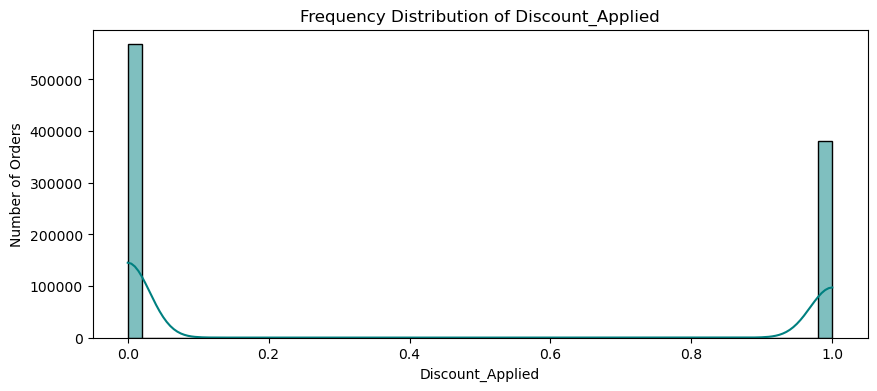

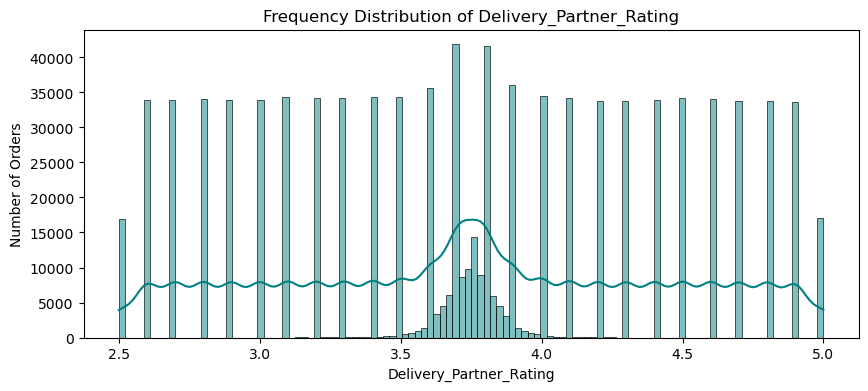

In [28]:
# First, define the cols variable with the column names you want to plot
# For example, if you want to plot histograms for all columns in the DataFrame:
cols = df.columns  # This assumes df is already defined

# Or if you want to plot specific columns:
# cols = ['column1', 'column2', 'column3']  # Replace with your actual column names

# Now the loop will work correctly
for col in cols:
    plt.figure(figsize=(10, 4))
    sns.histplot(df[col], kde=True, color="teal")
    plt.title(f'Frequency Distribution of {col}')
    plt.ylabel('Number of Orders')
    plt.show()

In [31]:
# 2) Filtering

df = df[df['Order_Value'] <= 2500]

In [32]:
# Summary Statistics

df.describe()

,Order_ID,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
count,9.477520e+05,947752.000000,947752.000000,947752.000000,947752.000000,947752.000000,947752.000000,947752.000000,947752.000000
mean,1.500028e+06,38.471165,570.912385,16.502070,7.750046,10.313292,3.042843,0.400786,3.749173
std,2.887273e+05,12.118982,374.174789,6.330106,4.186990,5.630770,1.161112,0.490058,0.684365
min,1.000001e+06,18.000000,50.000000,5.000000,0.500000,1.000000,1.000000,0.000000,2.500000
25%,1.249939e+06,28.000000,287.923000,12.362000,4.130000,5.000000,2.100000,0.000000,3.200000
50%,1.500026e+06,38.000000,531.674100,16.384000,7.750000,10.000000,3.015637,0.000000,3.753051
75%,1.750145e+06,49.000000,796.556650,20.302000,11.380000,15.000000,4.000000,1.000000,4.300000
max,2.000000e+06,59.000000,2492.435250,40.000000,15.000000,19.000000,5.000000,1.000000,5.000000


In [33]:
# Dataset Structure

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 947752 entries, 0 to 999999
Data columns (total 13 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Order_ID                 947752 non-null  int64  
 1   Company                  947752 non-null  object 
 2   City                     947752 non-null  object 
 3   Customer_Age             947752 non-null  int64  
 4   Order_Value              947752 non-null  float64
 5   Delivery_Time_Min        947752 non-null  float64
 6   Distance_Km              947752 non-null  float64
 7   Items_Count              947752 non-null  float64
 8   Product_Category         947752 non-null  object 
 9   Payment_Method           947752 non-null  object 
 10  Customer_Rating          947752 non-null  float64
 11  Discount_Applied         947752 non-null  int64  
 12  Delivery_Partner_Rating  947752 non-null  float64
dtypes: float64(6), int64(3), object(4)
memory usage: 101.2+ MB


Change Column Data-type

In [34]:
# Change data-type of Order ID

df['Order_ID'] =  df['Order_ID'].astype(str)

In [35]:
df.head()

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702.33750,19.182,11.97,12.0,Dairy,Wallet,2.1,1,3.2
1,1000002,Flipkart Minutes,Amritsar,56,1007.30000,19.644,12.74,10.0,Snacks,Cash on Delivery,2.3,0,3.2
2,1000003,Flipkart Minutes,Mumbai,18,1211.66000,16.910,4.85,19.0,Personal Care,Cash on Delivery,3.3,0,3.8
3,1000004,Swiggy Instamart,Delhi,23,1179.05925,5.864,6.44,2.0,Dairy,Credit Card,5.0,1,5.0
4,1000005,Dunzo,Mumbai,44,586.02550,12.470,2.45,13.0,Household,Wallet,3.7,0,4.8


In [36]:
# Round-off the float values

df['Order_Value'] = np.round(df['Order_Value'])

df['Delivery_Time_Min'] = np.round(df['Delivery_Time_Min'])

df['Distance_Km'] = np.round(df['Distance_Km'], 1)

df['Customer_Rating'] = np.round(df['Customer_Rating'])

df['Delivery_Partner_Rating'] = np.round(df['Delivery_Partner_Rating'])

In [37]:
df.head()

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702.0,19.0,12.0,12.0,Dairy,Wallet,2.0,1,3.0
1,1000002,Flipkart Minutes,Amritsar,56,1007.0,20.0,12.7,10.0,Snacks,Cash on Delivery,2.0,0,3.0
2,1000003,Flipkart Minutes,Mumbai,18,1212.0,17.0,4.8,19.0,Personal Care,Cash on Delivery,3.0,0,4.0
3,1000004,Swiggy Instamart,Delhi,23,1179.0,6.0,6.4,2.0,Dairy,Credit Card,5.0,1,5.0
4,1000005,Dunzo,Mumbai,44,586.0,12.0,2.4,13.0,Household,Wallet,4.0,0,5.0


In [38]:
# Change the data-type of float columns to integer

df['Order_Value'] = df['Order_Value'].astype(int)

df['Delivery_Time_Min'] = df['Delivery_Time_Min'].astype(int)

df['Items_Count'] = df['Items_Count'].astype(int)

df['Customer_Rating'] = df['Customer_Rating'].astype(int)

df['Delivery_Partner_Rating'] = df['Delivery_Partner_Rating'].astype(int)

In [39]:
df

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702,19,12.0,12,Dairy,Wallet,2,1,3
1,1000002,Flipkart Minutes,Amritsar,56,1007,20,12.7,10,Snacks,Cash on Delivery,2,0,3
2,1000003,Flipkart Minutes,Mumbai,18,1212,17,4.8,19,Personal Care,Cash on Delivery,3,0,4
3,1000004,Swiggy Instamart,Delhi,23,1179,6,6.4,2,Dairy,Credit Card,5,1,5
4,1000005,Dunzo,Mumbai,44,586,12,2.4,13,Household,Wallet,4,0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,1999996,Big Basket,Mumbai,48,72,18,3.0,19,Fruits & Vegetables,Wallet,4,0,3
999996,1999997,Swiggy Instamart,Mumbai,33,1510,18,10.5,9,Beverages,Debit Card,4,1,4
999997,1999998,Jio Mart,Noida,29,637,18,2.6,6,Groceries,Cash on Delivery,3,0,5
999998,1999999,Dunzo,Pune,42,1103,13,7.8,12,Snacks,Wallet,4,1,4


In [40]:
# Dataset Structure

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 947752 entries, 0 to 999999
Data columns (total 13 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Order_ID                 947752 non-null  object 
 1   Company                  947752 non-null  object 
 2   City                     947752 non-null  object 
 3   Customer_Age             947752 non-null  int64  
 4   Order_Value              947752 non-null  int64  
 5   Delivery_Time_Min        947752 non-null  int64  
 6   Distance_Km              947752 non-null  float64
 7   Items_Count              947752 non-null  int64  
 8   Product_Category         947752 non-null  object 
 9   Payment_Method           947752 non-null  object 
 10  Customer_Rating          947752 non-null  int64  
 11  Discount_Applied         947752 non-null  int64  
 12  Delivery_Partner_Rating  947752 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 101.2+ MB


Save Cleaned & Modified dataset

In [48]:

new_path = r"C:\Users\HP\Desktop\MY DATA SCIENCE\Quick commerce\Cleaned & Modified dataset\Q_commerce_data_modified_cleaned.csv"


In [49]:
df.to_csv(new_path, index = False)

# index=False : to remove the index

In [50]:
df = pd.read_csv(r"C:\Users\HP\Desktop\MY DATA SCIENCE\Quick commerce\Cleaned & Modified dataset\Q_commerce_data_modified_cleaned.csv")

In [51]:
df

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702,19,12.0,12,Dairy,Wallet,2,1,3
1,1000002,Flipkart Minutes,Amritsar,56,1007,20,12.7,10,Snacks,Cash on Delivery,2,0,3
2,1000003,Flipkart Minutes,Mumbai,18,1212,17,4.8,19,Personal Care,Cash on Delivery,3,0,4
3,1000004,Swiggy Instamart,Delhi,23,1179,6,6.4,2,Dairy,Credit Card,5,1,5
4,1000005,Dunzo,Mumbai,44,586,12,2.4,13,Household,Wallet,4,0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
947747,1999996,Big Basket,Mumbai,48,72,18,3.0,19,Fruits & Vegetables,Wallet,4,0,3
947748,1999997,Swiggy Instamart,Mumbai,33,1510,18,10.5,9,Beverages,Debit Card,4,1,4
947749,1999998,Jio Mart,Noida,29,637,18,2.6,6,Groceries,Cash on Delivery,3,0,5
947750,1999999,Dunzo,Pune,42,1103,13,7.8,12,Snacks,Wallet,4,1,4


>> Business Questionsor problems <<

Q.1) Which quick commerce platform has the highest total revenue?

In [52]:
df.head(10)

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702,19,12.0,12,Dairy,Wallet,2,1,3
1,1000002,Flipkart Minutes,Amritsar,56,1007,20,12.7,10,Snacks,Cash on Delivery,2,0,3
2,1000003,Flipkart Minutes,Mumbai,18,1212,17,4.8,19,Personal Care,Cash on Delivery,3,0,4
3,1000004,Swiggy Instamart,Delhi,23,1179,6,6.4,2,Dairy,Credit Card,5,1,5
4,1000005,Dunzo,Mumbai,44,586,12,2.4,13,Household,Wallet,4,0,5
5,1000006,Jio Mart,Kolkata,57,263,20,1.2,15,Snacks,UPI,3,0,5
6,1000007,Blinkit,Bengluru,37,517,18,12.5,19,Snacks,Debit Card,3,0,4
7,1000008,Dunzo,Chennai,49,292,11,4.9,2,Personal Care,Credit Card,3,0,5
8,1000009,Flipkart Minutes,Bengluru,26,763,18,10.3,5,Beverages,Wallet,2,0,3
9,1000010,Swiggy Instamart,Chennai,45,913,11,3.7,15,Groceries,Cash on Delivery,2,0,4


In [53]:
# Group Data - Calculate total order value for companies

company_revenue = df.groupby('Company')['Order_Value'].sum()

company_revenue

Company
Amazon Now          65832504
Big Basket          67884762
Blinkit             72499575
Dunzo               64007579
Flipkart Minutes    66998289
Jio Mart            57112860
Swiggy Instamart    76407756
Zepto               70339672
Name: Order_Value, dtype: int64

In [54]:
# Sort Grouped Data

company_revenue.sort_values()

Company
Jio Mart            57112860
Dunzo               64007579
Amazon Now          65832504
Flipkart Minutes    66998289
Big Basket          67884762
Zepto               70339672
Blinkit             72499575
Swiggy Instamart    76407756
Name: Order_Value, dtype: int64

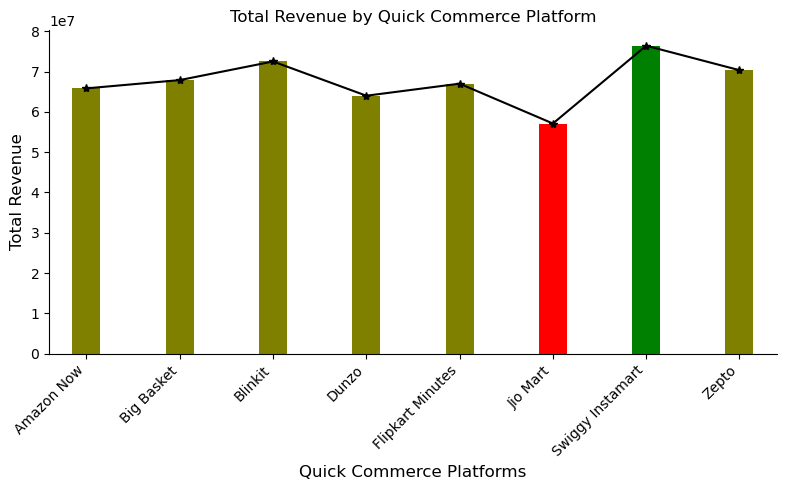

In [55]:
# Bar and Line Chart

plt.figure(figsize = (8,5))

# Find max and min revenue
max_val = company_revenue.max()
min_val = company_revenue.min()

# Assign colors based on value
colors = ['green' if val == max_val else
          'red' if val == min_val else
          'olive'
          for val in company_revenue          
         ]


# Draw Bar & Line Chart at once
company_revenue.plot( kind = 'bar', color = colors, width = 0.3)
company_revenue.plot( kind = 'line', color = 'black', marker = '*')

plt.xlabel("Quick Commerce Platforms", fontsize = 12)
plt.ylabel("Total Revenue", fontsize = 12)
plt.title("Total Revenue by Quick Commerce Platform")
plt.xticks(rotation=45, ha="right")

ax = plt.gca()    # gca - get current axis

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

plt.show()

Q.2) Which platform has the highest average order value (AOV)?

In [56]:
df.head()

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702,19,12.0,12,Dairy,Wallet,2,1,3
1,1000002,Flipkart Minutes,Amritsar,56,1007,20,12.7,10,Snacks,Cash on Delivery,2,0,3
2,1000003,Flipkart Minutes,Mumbai,18,1212,17,4.8,19,Personal Care,Cash on Delivery,3,0,4
3,1000004,Swiggy Instamart,Delhi,23,1179,6,6.4,2,Dairy,Credit Card,5,1,5
4,1000005,Dunzo,Mumbai,44,586,12,2.4,13,Household,Wallet,4,0,5


In [57]:
# Group Data - Calculate average order value for companies

df.groupby('Company')['Order_Value'].mean()

Company
Amazon Now          557.510429
Big Basket          575.065542
Blinkit             609.819198
Dunzo               540.317053
Flipkart Minutes    563.176472
Jio Mart            482.914592
Swiggy Instamart    644.927250
Zepto               593.258314
Name: Order_Value, dtype: float64

In [58]:
AOV =  df.groupby('Company')['Order_Value'].mean().sort_values()

AOV

Company
Jio Mart            482.914592
Dunzo               540.317053
Amazon Now          557.510429
Flipkart Minutes    563.176472
Big Basket          575.065542
Zepto               593.258314
Blinkit             609.819198
Swiggy Instamart    644.927250
Name: Order_Value, dtype: float64

In [59]:
type(AOV)

pandas.core.series.Series

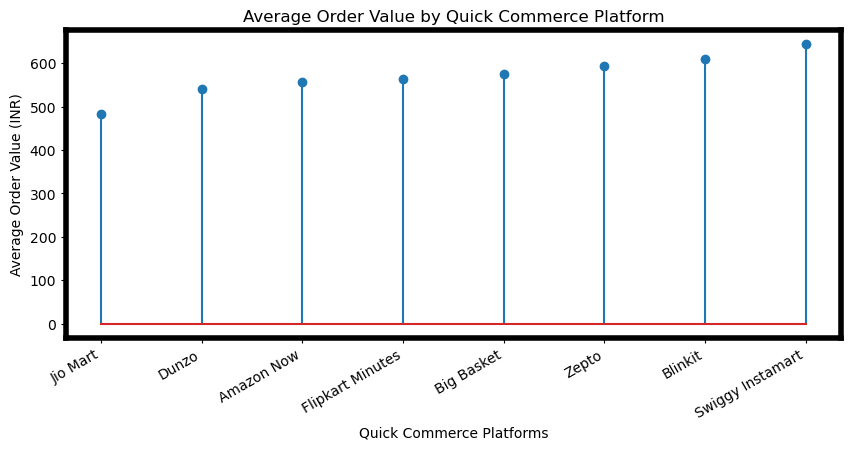

In [61]:
# Stem Chart

plt.figure(figsize = (10,4))

plt.stem(AOV.index, AOV.values)         # stem chart

plt.xlabel("Quick Commerce Platforms")
plt.ylabel("Average Order Value (INR)")
plt.title("Average Order Value by Quick Commerce Platform")
plt.xticks(rotation=30, ha="right")

ax = plt.gca()

# Highlight all four borders
ax.spines['top'].set_linewidth(4)
ax.spines['bottom'].set_linewidth(4)
ax.spines['right'].set_linewidth(4)
ax.spines['left'].set_linewidth(4)



Q.3) How does Customer Rating vary across platforms?

In [65]:
df.head()

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702,19,12.0,12,Dairy,Wallet,2,1,3
1,1000002,Flipkart Minutes,Amritsar,56,1007,20,12.7,10,Snacks,Cash on Delivery,2,0,3
2,1000003,Flipkart Minutes,Mumbai,18,1212,17,4.8,19,Personal Care,Cash on Delivery,3,0,4
3,1000004,Swiggy Instamart,Delhi,23,1179,6,6.4,2,Dairy,Credit Card,5,1,5
4,1000005,Dunzo,Mumbai,44,586,12,2.4,13,Household,Wallet,4,0,5


In [66]:
# Group Data - Calculate average rating for companies

df.groupby('Company')['Customer_Rating'].mean().sort_values()

Company
Dunzo               2.428024
Jio Mart            2.819747
Amazon Now          2.913417
Flipkart Minutes    3.016316
Big Basket          3.097902
Zepto               3.203062
Swiggy Instamart    3.279443
Blinkit             3.580762
Name: Customer_Rating, dtype: float64

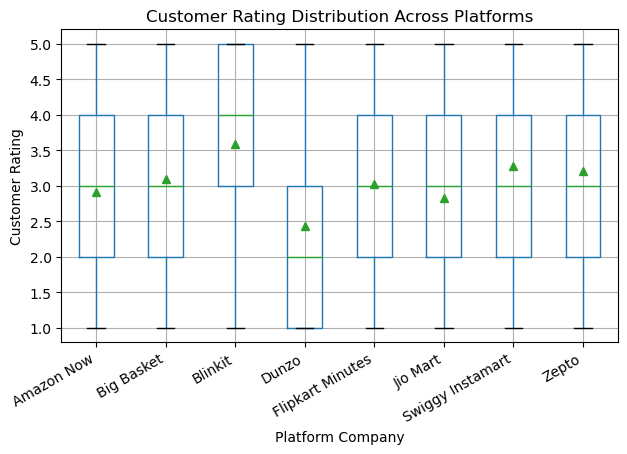

In [67]:
# Box Plot

df.boxplot(column = 'Customer_Rating', by = 'Company', showmeans = True)

plt.title("Customer Rating Distribution Across Platforms")

plt.suptitle("") # Remove default pandas title

plt.xlabel("Platform Company")
plt.ylabel("Customer Rating")
plt.xticks(rotation = 30, ha = 'right')    # ⬅️ Rotate labels for clarity

plt.tight_layout()                  # ⬅️ Auto adjust spacing
plt.show()

In [68]:
# Group Data

grouped_rating =  df.groupby(['Company', 'Customer_Rating']).size().unstack(fill_value=0)

grouped_rating

Customer_Rating,1,2,3,4,5
Company,,,,,
Amazon Now,15977,30351,30866,29697,11192
Big Basket,10143,30339,31020,30908,15637
Blinkit,1060,25553,25561,36708,30005
Dunzo,29818,36280,25377,25818,1170
Flipkart Minutes,12549,30786,31225,30985,13420
Jio Mart,18513,30515,31083,30089,8067
Swiggy Instamart,5000,30278,31039,30931,21227
Zepto,7618,29763,31367,30559,19258


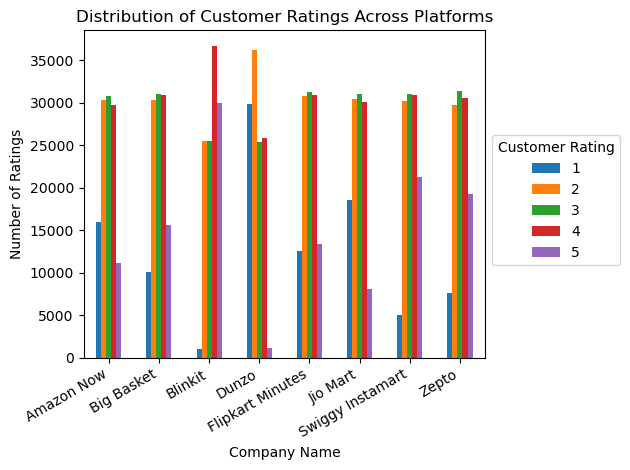

In [69]:
# Bar Chart for Grouped Ratings

grouped_rating.plot(kind = 'bar')

plt.xlabel("Company Name")
plt.ylabel("Number of Ratings")
plt.title("Distribution of Customer Ratings Across Platforms")

plt.legend(title = 'Customer Rating', bbox_to_anchor = (1, 0.7), loc = 'upper left')

plt.xticks(rotation = 30, ha = 'right')

plt.tight_layout()
plt.show()

Q.4) Does 'Delivery Time' affects the 'Delivery Partner Ratings'?

In [70]:
df.head()

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702,19,12.0,12,Dairy,Wallet,2,1,3
1,1000002,Flipkart Minutes,Amritsar,56,1007,20,12.7,10,Snacks,Cash on Delivery,2,0,3
2,1000003,Flipkart Minutes,Mumbai,18,1212,17,4.8,19,Personal Care,Cash on Delivery,3,0,4
3,1000004,Swiggy Instamart,Delhi,23,1179,6,6.4,2,Dairy,Credit Card,5,1,5
4,1000005,Dunzo,Mumbai,44,586,12,2.4,13,Household,Wallet,4,0,5


In [71]:
df['Delivery_Time_Min'].mean()

np.float64(16.506619875241626)

In [72]:
df['Delivery_Partner_Rating'].mean()

np.float64(3.80029480285982)

In [73]:
# Calculate average rating for delivery timings

x = df.groupby('Delivery_Time_Min')['Delivery_Partner_Rating'].mean()

x

Delivery_Time_Min
5     3.803956
6     3.798555
7     3.805901
8     3.803807
9     3.804469
10    3.801688
11    3.799953
12    3.798843
13    3.795841
14    3.797351
15    3.797958
16    3.799191
17    3.802405
18    3.801744
19    3.809601
20    3.804773
21    3.803036
22    3.804585
23    3.794215
24    3.791258
25    3.800221
26    3.795316
27    3.799794
28    3.796314
29    3.792997
30    3.788537
31    3.807610
32    3.789012
33    3.781402
34    3.770451
35    3.779251
36    3.752239
37    3.732039
38    3.741307
39    3.799097
40    3.737589
Name: Delivery_Partner_Rating, dtype: float64

In [74]:
df['Delivery_Time_Min'].corr(df['Delivery_Partner_Rating'])

np.float64(-0.002777340802669752)

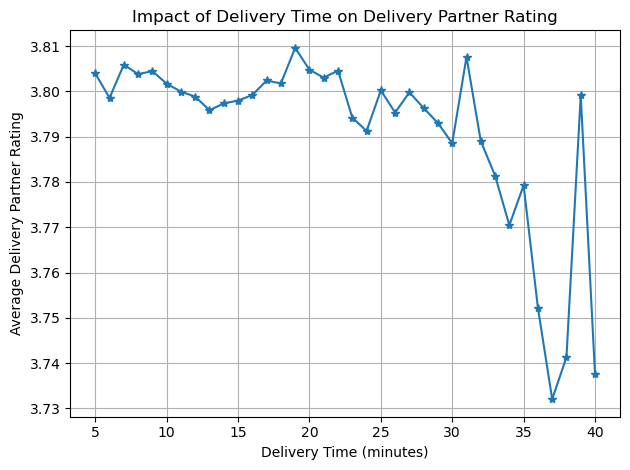

In [75]:
# Line Chart

x.plot(marker = '*')

plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Average Delivery Partner Rating")
plt.title("Impact of Delivery Time on Delivery Partner Rating")
plt.grid(True)

plt.tight_layout()
plt.show()

In [76]:
#syntax : pd.cut( col_name, bins, labels )

df['Delivery_Time_Bucket'] = pd.cut( 
                                    df['Delivery_Time_Min'], 
                                    bins = (0,10,20,30,40,50),
                                    labels = ("Very Fast Delivery", "Fast Delivery", 'Normal Delivery', 
                                              'Slow Delivery', 'Very Slow Delivery'))

In [77]:
df

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating,Delivery_Time_Bucket
0,1000001,Swiggy Instamart,Noida,46,702,19,12.0,12,Dairy,Wallet,2,1,3,Fast Delivery
1,1000002,Flipkart Minutes,Amritsar,56,1007,20,12.7,10,Snacks,Cash on Delivery,2,0,3,Fast Delivery
2,1000003,Flipkart Minutes,Mumbai,18,1212,17,4.8,19,Personal Care,Cash on Delivery,3,0,4,Fast Delivery
3,1000004,Swiggy Instamart,Delhi,23,1179,6,6.4,2,Dairy,Credit Card,5,1,5,Very Fast Delivery
4,1000005,Dunzo,Mumbai,44,586,12,2.4,13,Household,Wallet,4,0,5,Fast Delivery
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
947747,1999996,Big Basket,Mumbai,48,72,18,3.0,19,Fruits & Vegetables,Wallet,4,0,3,Fast Delivery
947748,1999997,Swiggy Instamart,Mumbai,33,1510,18,10.5,9,Beverages,Debit Card,4,1,4,Fast Delivery
947749,1999998,Jio Mart,Noida,29,637,18,2.6,6,Groceries,Cash on Delivery,3,0,5,Fast Delivery
947750,1999999,Dunzo,Pune,42,1103,13,7.8,12,Snacks,Wallet,4,1,4,Fast Delivery


In [78]:
bucket_avg = df.groupby('Delivery_Time_Bucket')['Delivery_Partner_Rating'].mean()

bucket_avg

C:\Users\HP\AppData\Local\Temp\ipykernel_14332\1409831079.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bucket_avg = df.groupby('Delivery_Time_Bucket')['Delivery_Partner_Rating'].mean()


Delivery_Time_Bucket
Very Fast Delivery    3.803231
Fast Delivery         3.800835
Normal Delivery       3.798345
Slow Delivery         3.783646
Very Slow Delivery         NaN
Name: Delivery_Partner_Rating, dtype: float64

In [79]:
df['Delivery_Time_Min'].max()

40

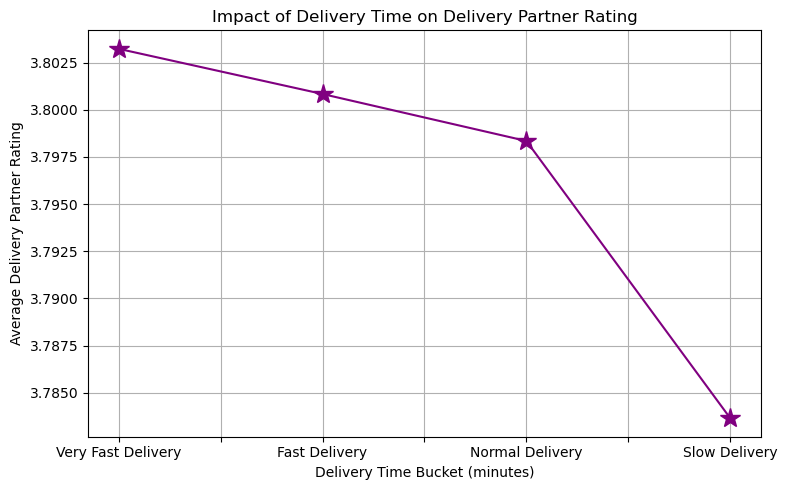

In [80]:
plt.figure(figsize=(8,5))

bucket_avg.plot(marker = '*', markersize = 15, color = 'purple')

plt.xlabel("Delivery Time Bucket (minutes)")
plt.ylabel("Average Delivery Partner Rating")
plt.title("Impact of Delivery Time on Delivery Partner Rating")
plt.grid(True)


plt.tight_layout()
plt.show()

Q.5) What is the most popular Product Category on Swiggy Instamart, for the people of age between 30-40, in Mumbai?

In [81]:
df.head()

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating,Delivery_Time_Bucket
0,1000001,Swiggy Instamart,Noida,46,702,19,12.0,12,Dairy,Wallet,2,1,3,Fast Delivery
1,1000002,Flipkart Minutes,Amritsar,56,1007,20,12.7,10,Snacks,Cash on Delivery,2,0,3,Fast Delivery
2,1000003,Flipkart Minutes,Mumbai,18,1212,17,4.8,19,Personal Care,Cash on Delivery,3,0,4,Fast Delivery
3,1000004,Swiggy Instamart,Delhi,23,1179,6,6.4,2,Dairy,Credit Card,5,1,5,Very Fast Delivery
4,1000005,Dunzo,Mumbai,44,586,12,2.4,13,Household,Wallet,4,0,5,Fast Delivery


In [82]:
# filtering

df_pc = df[
           (df['Company'] ==  'Swiggy Instamart') &
           ((df['Customer_Age'] >= 30) & (df['Customer_Age'] < 40)) &
           (df['City'] == 'Mumbai')
           ]

df_pc

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating,Delivery_Time_Bucket
512,1000537,Swiggy Instamart,Mumbai,38,1157,14,5.7,18,Beverages,Cash on Delivery,4,1,4,Fast Delivery
872,1000910,Swiggy Instamart,Mumbai,32,926,20,14.2,3,Dairy,UPI,2,0,5,Fast Delivery
1148,1001204,Swiggy Instamart,Mumbai,37,234,19,7.6,6,Dairy,Debit Card,5,0,4,Fast Delivery
2783,1002919,Swiggy Instamart,Mumbai,31,423,15,4.0,10,Dairy,Cash on Delivery,2,0,3,Fast Delivery
4038,1004252,Swiggy Instamart,Mumbai,36,50,15,2.2,12,Dairy,Credit Card,3,0,3,Fast Delivery
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
945478,1997611,Swiggy Instamart,Mumbai,37,448,19,14.0,17,Fruits & Vegetables,Cash on Delivery,5,0,5,Fast Delivery
947020,1999243,Swiggy Instamart,Mumbai,32,747,13,2.4,12,Household,UPI,5,1,5,Fast Delivery
947036,1999259,Swiggy Instamart,Mumbai,35,50,18,7.6,4,Personal Care,Debit Card,5,0,5,Fast Delivery
947444,1999681,Swiggy Instamart,Mumbai,39,375,19,8.7,6,Household,Wallet,2,0,4,Fast Delivery


In [83]:
# Most popular product category

df_pc['Product_Category'].value_counts()

Product_Category
Dairy                  368
Fruits & Vegetables    343
Groceries              341
Household              340
Snacks                 329
Personal Care          305
Beverages              299
Name: count, dtype: int64

Q.6) Which cities should these company expand into based on performance?

In [84]:
df.head()

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating,Delivery_Time_Bucket
0,1000001,Swiggy Instamart,Noida,46,702,19,12.0,12,Dairy,Wallet,2,1,3,Fast Delivery
1,1000002,Flipkart Minutes,Amritsar,56,1007,20,12.7,10,Snacks,Cash on Delivery,2,0,3,Fast Delivery
2,1000003,Flipkart Minutes,Mumbai,18,1212,17,4.8,19,Personal Care,Cash on Delivery,3,0,4,Fast Delivery
3,1000004,Swiggy Instamart,Delhi,23,1179,6,6.4,2,Dairy,Credit Card,5,1,5,Very Fast Delivery
4,1000005,Dunzo,Mumbai,44,586,12,2.4,13,Household,Wallet,4,0,5,Fast Delivery


In [85]:
# Group Data and Apply Aggregate functions

city_perf = df.groupby(['Company', 'City']).agg(
                                               Total_Orders = ('Order_ID', 'count'),
                                               Avg_Rating=("Customer_Rating", 'mean'),
                                               Avg_Delivery_Time=('Delivery_Time_Min', 'mean'),
                                               Total_Revenue=('Order_Value', 'sum')
                                                ).reset_index()

In [86]:
city_perf

,Company,City,Total_Orders,Avg_Rating,Avg_Delivery_Time,Total_Revenue
0,Amazon Now,Amritsar,9929,2.896666,18.167388,5469439
1,Amazon Now,Bengluru,9905,3.387683,19.183342,5629936
2,Amazon Now,Chennai,9847,2.904032,18.138722,5363559
3,Amazon Now,Delhi,9918,2.989716,8.294616,5891026
4,Amazon Now,Gurgaon,9797,2.921711,18.166173,6680388
...,...,...,...,...,...,...
91,Zepto,Jaipur,9678,3.112213,13.145278,4621428
92,Zepto,Kolkata,9825,3.173028,8.302901,5776955
93,Zepto,Mumbai,9861,3.412230,10.152013,6046485
94,Zepto,Noida,10070,3.206653,8.297617,7070769


In [87]:
# Filtering Best Cities based on given condition

best_cities = city_perf[
                        (city_perf['Avg_Rating'] >= 3.5) &
                        (city_perf['Avg_Delivery_Time'] <= 15) &
                        (city_perf['Total_Orders'] > city_perf['Total_Orders'].median())
                        ]

In [88]:
best_cities

,Company,City,Total_Orders,Avg_Rating,Avg_Delivery_Time,Total_Revenue
24,Blinkit,Amritsar,9932,3.589106,14.199154,6006361
26,Blinkit,Chennai,9876,3.580903,14.135581,5921870
28,Blinkit,Gurgaon,10078,3.579381,14.199345,7374774
32,Blinkit,Kolkata,10004,3.566873,14.142743,6003384
35,Blinkit,Pune,9908,3.583266,14.164110,5930415
85,Zepto,Bengluru,9971,3.598636,9.198977,6041668


In [89]:
best_cities[['Company', 'City']]

,Company,City
24,Blinkit,Amritsar
26,Blinkit,Chennai
28,Blinkit,Gurgaon
32,Blinkit,Kolkata
35,Blinkit,Pune
85,Zepto,Bengluru


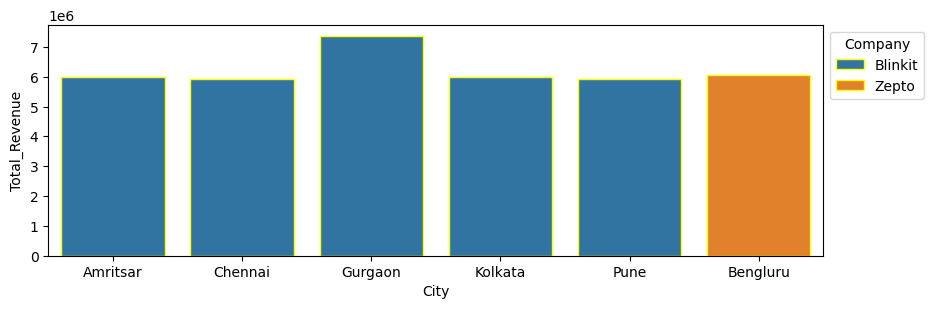

In [90]:
plt.figure(figsize = (10,3))

sns.barplot( data = best_cities, x = 'City', y ='Total_Revenue', hue = 'Company', edgecolor = 'yellow')

plt.legend(title = 'Company', bbox_to_anchor = (1, 1))

plt.show()

Q.7) Are discounts increasing order volume or just reducing revenue?

In [92]:
df.head()

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating,Delivery_Time_Bucket
0,1000001,Swiggy Instamart,Noida,46,702,19,12.0,12,Dairy,Wallet,2,1,3,Fast Delivery
1,1000002,Flipkart Minutes,Amritsar,56,1007,20,12.7,10,Snacks,Cash on Delivery,2,0,3,Fast Delivery
2,1000003,Flipkart Minutes,Mumbai,18,1212,17,4.8,19,Personal Care,Cash on Delivery,3,0,4,Fast Delivery
3,1000004,Swiggy Instamart,Delhi,23,1179,6,6.4,2,Dairy,Credit Card,5,1,5,Very Fast Delivery
4,1000005,Dunzo,Mumbai,44,586,12,2.4,13,Household,Wallet,4,0,5,Fast Delivery


In [93]:
# Count the number of orders with and without discount

df['Discount_Applied'].value_counts()

Discount_Applied
0    567906
1    379846
Name: count, dtype: int64

In [94]:
# Group Data - Calculate average order value

dis_order_value = df.groupby('Discount_Applied')['Order_Value'].mean()

dis_order_value

Discount_Applied
0    476.417152
1    712.190830
Name: Order_Value, dtype: float64

In [95]:
# Group Data - Calculate sum of items count

dis_items_count = df.groupby('Discount_Applied')['Items_Count'].sum()

dis_items_count

Discount_Applied
0    5854258
1    3920185
Name: Items_Count, dtype: int64

In [96]:
x = df['Discount_Applied'].unique()
print(x)

[1 0]


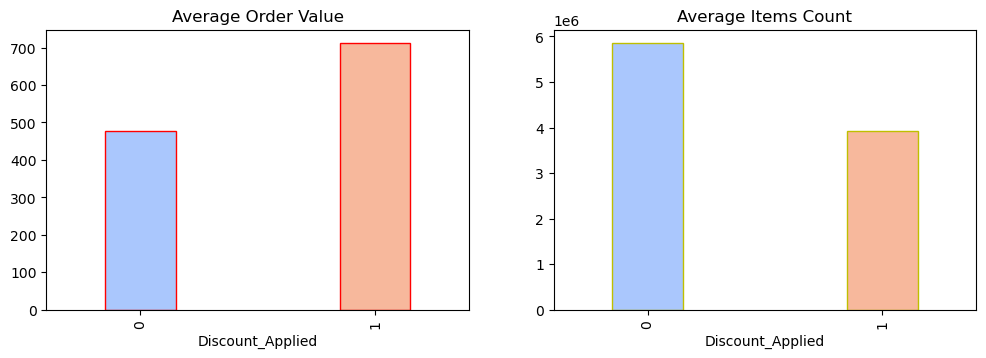

In [97]:
plt.figure(figsize=(12,8))

# use gradient colors
colors = sns.color_palette("coolwarm", len(x))

plt.subplot(2,2,1)
dis_order_value.plot(kind = 'bar', width = 0.3, edgecolor = 'red', color = colors)
plt.title("Average Order Value")

plt.subplot(2,2,2)
dis_items_count.plot(kind = 'bar', width = 0.3, edgecolor = 'y', color = colors)
plt.title("Average Items Count")


plt.show()

Q.8) Which company has the Best Operational Efficiency (Delivery Time vs Order Volume)?¶

In [98]:
df.head()

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating,Delivery_Time_Bucket
0,1000001,Swiggy Instamart,Noida,46,702,19,12.0,12,Dairy,Wallet,2,1,3,Fast Delivery
1,1000002,Flipkart Minutes,Amritsar,56,1007,20,12.7,10,Snacks,Cash on Delivery,2,0,3,Fast Delivery
2,1000003,Flipkart Minutes,Mumbai,18,1212,17,4.8,19,Personal Care,Cash on Delivery,3,0,4,Fast Delivery
3,1000004,Swiggy Instamart,Delhi,23,1179,6,6.4,2,Dairy,Credit Card,5,1,5,Very Fast Delivery
4,1000005,Dunzo,Mumbai,44,586,12,2.4,13,Household,Wallet,4,0,5,Fast Delivery


In [99]:
# Group Data and Apply Aggregate functions

company_efficiency =  df.groupby('Company').agg(
                                                Total_Orders = ('Order_ID', 'count'),
                                                Avg_Delivery_Time = ('Delivery_Time_Min', 'mean')
                                                ).reset_index()

company_efficiency

,Company,Total_Orders,Avg_Delivery_Time
0,Amazon Now,118083,18.984155
1,Big Basket,118047,18.027345
2,Blinkit,118887,15.121771
3,Dunzo,118463,14.177060
4,Flipkart Minutes,118965,17.045080
5,Jio Mart,118267,23.013224
6,Swiggy Instamart,118475,16.072690
7,Zepto,118565,9.644313


In [100]:
# Normalize values for fair comparison

from sklearn.preprocessing import MinMaxScaler

# Scaling both columns to the same range (0 to 1) so that they can be fairly compared and combined.

scaler = MinMaxScaler()   # Create a scaling object

company_efficiency[['Total_Orders_Scaled', 'Avg_Delivery_Time_Scaled']] = scaler.fit_transform(
                  company_efficiency[['Total_Orders', 'Avg_Delivery_Time']]
                                                                                                )

In [101]:
company_efficiency

,Company,Total_Orders,Avg_Delivery_Time,Total_Orders_Scaled,Avg_Delivery_Time_Scaled
0,Amazon Now,118083,18.984155,0.039216,0.698624
1,Big Basket,118047,18.027345,0.000000,0.627054
2,Blinkit,118887,15.121771,0.915033,0.409716
3,Dunzo,118463,14.177060,0.453159,0.339051
4,Flipkart Minutes,118965,17.045080,1.000000,0.553580
5,Jio Mart,118267,23.013224,0.239651,1.000000
6,Swiggy Instamart,118475,16.072690,0.466231,0.480845
7,Zepto,118565,9.644313,0.564270,0.000000


In [102]:
# Efficiency Score (higher orders, lower time)

company_efficiency['Efficiency_Score'] = company_efficiency['Total_Orders_Scaled'] - company_efficiency['Avg_Delivery_Time_Scaled']

In [103]:
company_efficiency

,Company,Total_Orders,Avg_Delivery_Time,Total_Orders_Scaled,Avg_Delivery_Time_Scaled,Efficiency_Score
0,Amazon Now,118083,18.984155,0.039216,0.698624,-0.659408
1,Big Basket,118047,18.027345,0.000000,0.627054,-0.627054
2,Blinkit,118887,15.121771,0.915033,0.409716,0.505317
3,Dunzo,118463,14.177060,0.453159,0.339051,0.114108
4,Flipkart Minutes,118965,17.045080,1.000000,0.553580,0.446420
5,Jio Mart,118267,23.013224,0.239651,1.000000,-0.760349
6,Swiggy Instamart,118475,16.072690,0.466231,0.480845,-0.014614
7,Zepto,118565,9.644313,0.564270,0.000000,0.564270


In [104]:
# Sort by best efficiency

eff = company_efficiency.sort_values(by = 'Efficiency_Score', ascending = False)

eff

,Company,Total_Orders,Avg_Delivery_Time,Total_Orders_Scaled,Avg_Delivery_Time_Scaled,Efficiency_Score
7,Zepto,118565,9.644313,0.564270,0.000000,0.564270
2,Blinkit,118887,15.121771,0.915033,0.409716,0.505317
4,Flipkart Minutes,118965,17.045080,1.000000,0.553580,0.446420
3,Dunzo,118463,14.177060,0.453159,0.339051,0.114108
6,Swiggy Instamart,118475,16.072690,0.466231,0.480845,-0.014614
1,Big Basket,118047,18.027345,0.000000,0.627054,-0.627054
0,Amazon Now,118083,18.984155,0.039216,0.698624,-0.659408
5,Jio Mart,118267,23.013224,0.239651,1.000000,-0.760349


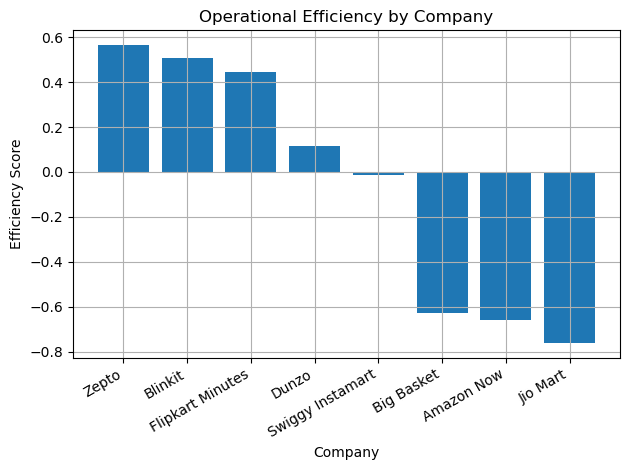

In [105]:
# Plot

# Sort by Efficiency Score (best first)
plt.bar( eff['Company'], eff['Efficiency_Score'])

plt.xlabel("Company")
plt.ylabel("Efficiency Score")
plt.title("Operational Efficiency by Company")

plt.xticks(rotation = 30, ha = 'right')

plt.grid(True)

plt.tight_layout()
plt.show()

In [106]:
eff

,Company,Total_Orders,Avg_Delivery_Time,Total_Orders_Scaled,Avg_Delivery_Time_Scaled,Efficiency_Score
7,Zepto,118565,9.644313,0.564270,0.000000,0.564270
2,Blinkit,118887,15.121771,0.915033,0.409716,0.505317
4,Flipkart Minutes,118965,17.045080,1.000000,0.553580,0.446420
3,Dunzo,118463,14.177060,0.453159,0.339051,0.114108
6,Swiggy Instamart,118475,16.072690,0.466231,0.480845,-0.014614
1,Big Basket,118047,18.027345,0.000000,0.627054,-0.627054
0,Amazon Now,118083,18.984155,0.039216,0.698624,-0.659408
5,Jio Mart,118267,23.013224,0.239651,1.000000,-0.760349


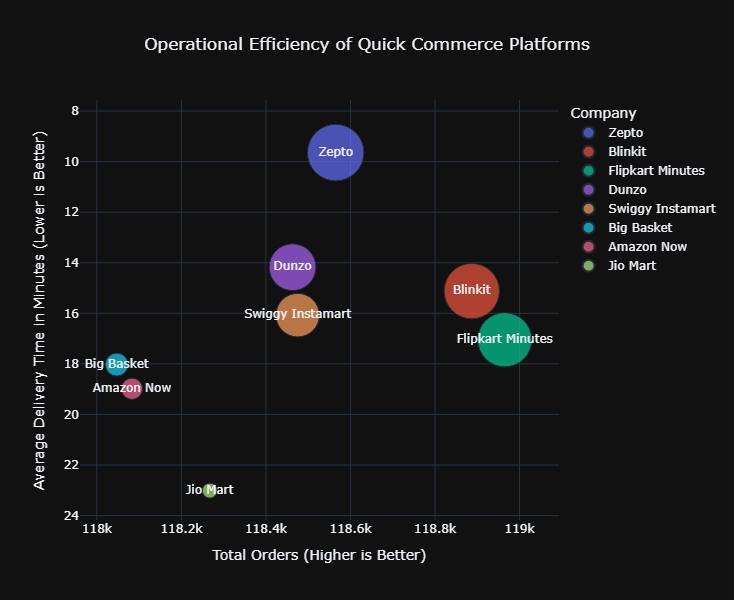

In [107]:
# Use Plotly Library - Scatter Bubble Plot

import plotly.express as px

# Create positive bubble size
min_eff = eff['Efficiency_Score'].min()
eff['Bubble_Size'] = eff['Efficiency_Score'] - min_eff + 0.1


# Plot
fig = px.scatter( eff, x = "Total_Orders" , y = 'Avg_Delivery_Time', size = 'Bubble_Size', color = 'Company',
                text = 'Company', title = "Operational Efficiency of Quick Commerce Platforms",
                hover_data = { 'Total_Orders': True, "Avg_Delivery_Time": ':.2f', 'Efficiency_Score': ':.3f' },
                size_max = 40)

# Make labels cleaner
fig.update_traces(textposition = 'middle center')

# Improve Chart
fig.update_layout( 
                    xaxis_title="Total Orders (Higher is Better)",
                    yaxis_title="Average Delivery Time in Minutes (Lower is Better)",
                    title_x=0.5,
                    template="plotly_dark",
                    height = 600
                    )

# Reverse Y-axis so best performers appear higher
fig.update_yaxes( autorange = 'reversed' )


fig.show()

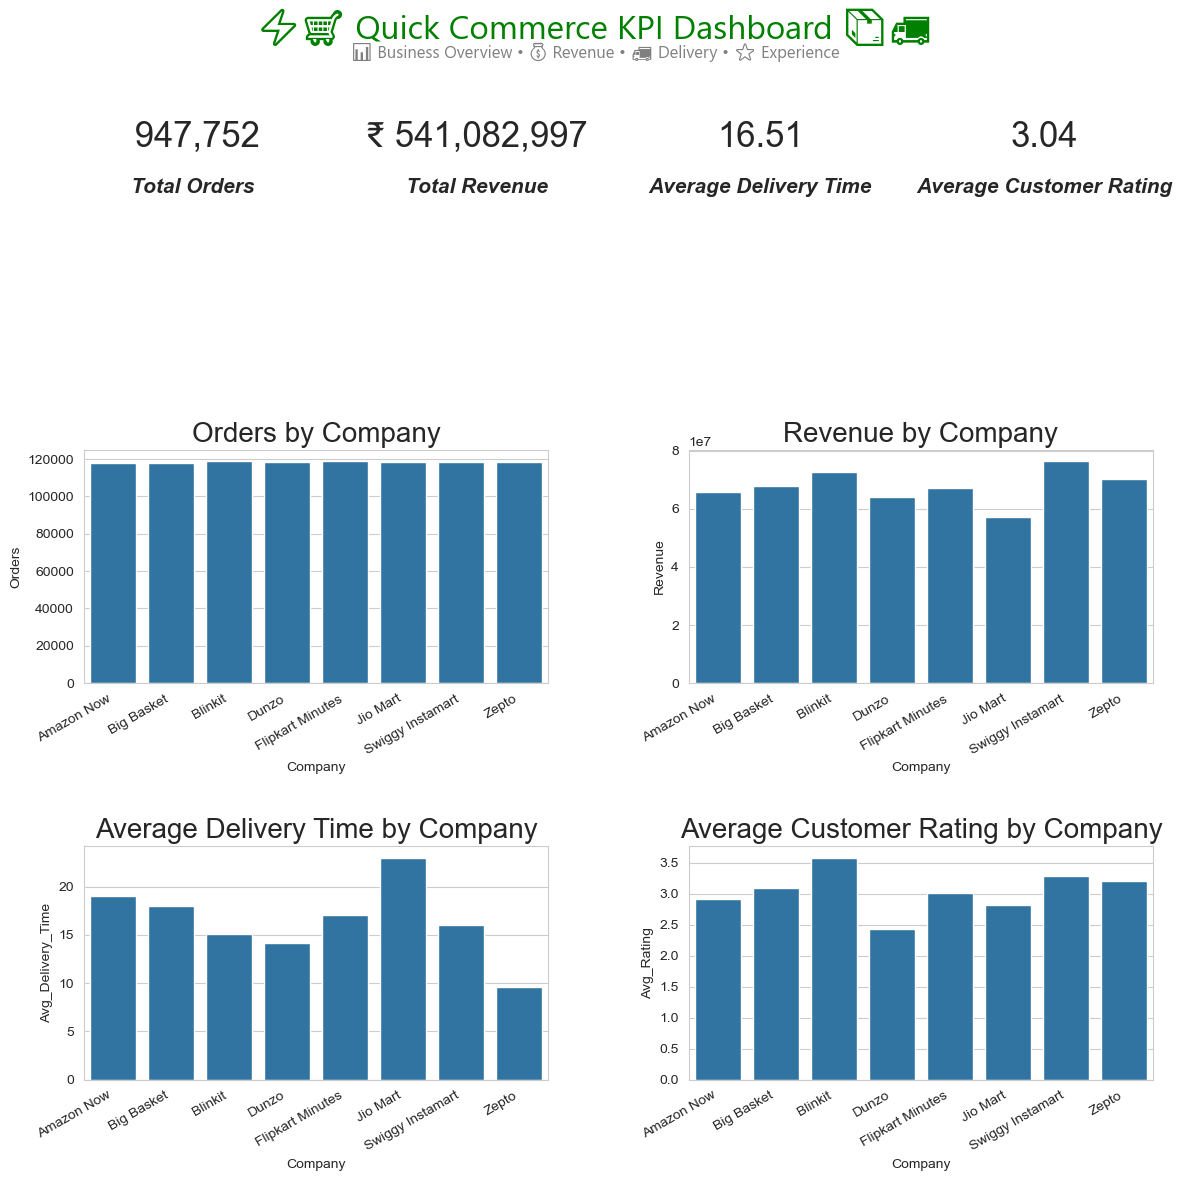

In [110]:
# Create Dashboard Layout
# --------------------

fig = plt.figure(figsize = (12,12))

sns.set_style("whitegrid")

# --------------------
# KPI Calculations
# --------------------

total_orders =  df['Order_ID'].count()
total_revenue = df['Order_Value'].sum()
avg_delivery_time = df['Delivery_Time_Min'].mean()
avg_rating = df['Customer_Rating'].mean()


# --------------------
# KPI CARDS
# --------------------

plt.subplot2grid((3,4), (0,0))
plt.axis('off')
plt.text(0.5, 0.6, f"{total_orders: ,}", fontsize = 25, ha = 'center')
plt.text(0.5, 0.4, "Total Orders", fontsize = 15, ha = 'center', fontstyle = 'italic', fontweight = 'bold')

plt.subplot2grid((3,4), (0,1))
plt.axis('off')
plt.text(0.5, 0.6, f"₹{total_revenue: ,}", fontsize = 25, ha = 'center')
plt.text(0.5, 0.4, "Total Revenue", fontsize = 15, ha = 'center', fontstyle = 'italic', fontweight = 'bold')

plt.subplot2grid((3,4), (0,2))
plt.axis('off')
plt.text(0.5, 0.6, f"{avg_delivery_time:.2f}", fontsize = 25, ha = 'center')
plt.text(0.5, 0.4, "Average Delivery Time", fontsize = 15, ha = 'center', fontstyle = 'italic', fontweight = 'bold')

plt.subplot2grid((3,4), (0,3))
plt.axis('off')
plt.text(0.5, 0.6, f"{avg_rating:.2f}", fontsize = 25, ha = 'center')
plt.text(0.5, 0.4, "Average Customer Rating", fontsize = 15, ha = 'center', fontstyle = 'italic', fontweight = 'bold')


# --------------------
# Company Level Metrics
# --------------------

company_metrics =  df.groupby('Company').agg( Orders = ('Order_ID', 'count'),
                                             Revenue = ("Order_Value", 'sum'),
                                             Avg_Delivery_Time = ("Delivery_Time_Min", 'mean'),
                                             Avg_Rating = ("Customer_Rating", 'mean')).reset_index()

# --------------------
# Charts Section
# --------------------

# Orders by company
plt.subplot2grid((3,2), (1,0))
sns.barplot( data = company_metrics , x = 'Company', y = 'Orders')
plt.title("Orders by Company", fontsize = 20)
plt.xticks(rotation=30, ha = 'right')

# Revenue by company
plt.subplot2grid((3,2), (1,1))
sns.barplot( data = company_metrics , x = 'Company', y = 'Revenue')
plt.title("Revenue by Company", fontsize = 20)
plt.xticks(rotation=30, ha = 'right')

# Avg delivery time by company
plt.subplot2grid((3,2), (2,0))
sns.barplot( data = company_metrics , x = 'Company', y = 'Avg_Delivery_Time')
plt.title("Average Delivery Time by Company", fontsize = 20)
plt.xticks(rotation=30, ha = 'right')

# Avg rating by company
plt.subplot2grid((3,2), (2,1))
sns.barplot( data = company_metrics , x = 'Company', y = 'Avg_Rating')
plt.title("Average Customer Rating by Company", fontsize = 20)
plt.xticks(rotation=30, ha = 'right')

# --------------------
# Dashboard Title
# --------------------

plt.rcParams['font.family'] = "Segoe UI Emoji"

plt.suptitle("⚡🛒 Quick Commerce KPI Dashboard 📦🚚", fontsize = 24, color = 'green' )

plt.figtext(0.5, 0.94, "📊 Business Overview • 💰 Revenue • 🚚 Delivery • ⭐ Experience", ha = 'center',
           fontsize = 12, color = 'gray')


plt.tight_layout()
plt.subplots_adjust(hspace = 0.7)
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_14332\320525227.py:48: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\HP\AppData\Local\Temp\ipykernel_14332\320525227.py:54: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\HP\AppData\Local\Temp\ipykernel_14332\320525227.py:60: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\HP\AppData\Local\Temp\ipykernel_14332\320525227.py:66: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\U

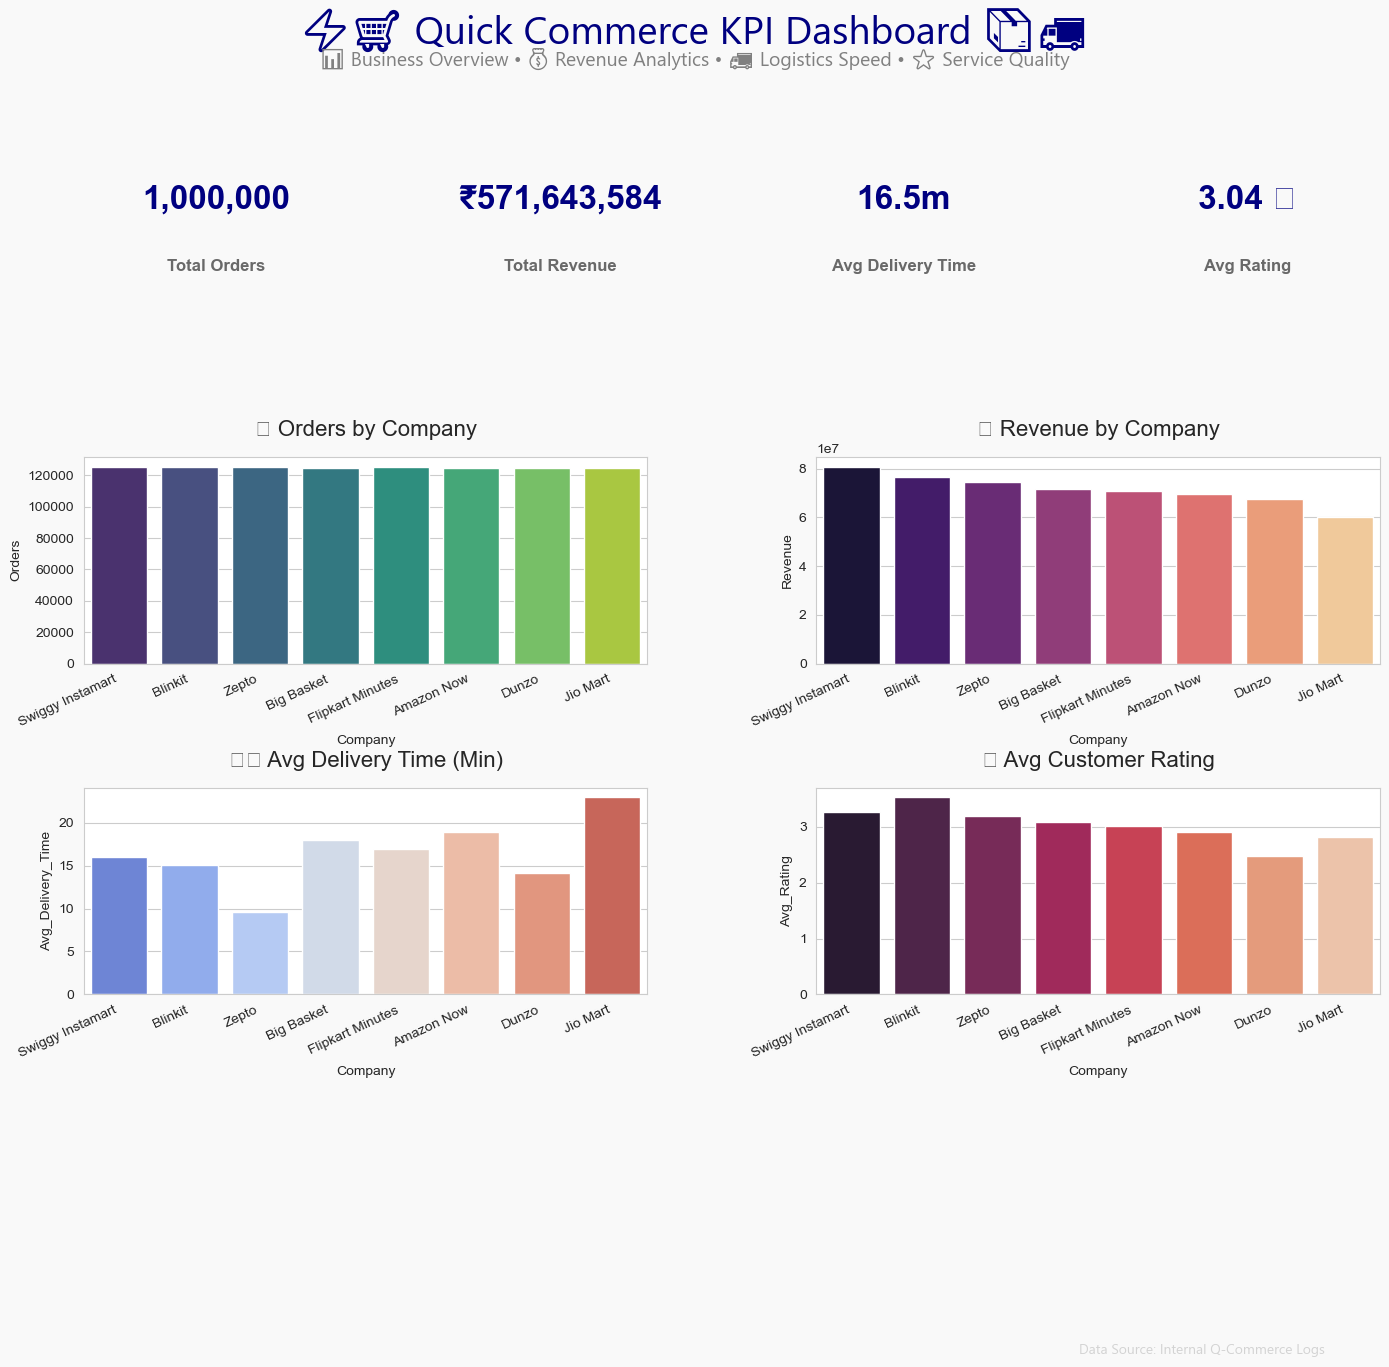

In [113]:
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------
# Create Dashboard Layout
# --------------------
fig = plt.figure(figsize=(14, 14), facecolor='#F9F9F9') # Added background color
sns.set_style("whitegrid")

# --------------------
# KPI Calculations
# --------------------
total_orders = df['Order_ID'].count()
total_revenue = df['Order_Value'].sum()
avg_delivery_time = df['Delivery_Time_Min'].mean()
avg_rating = df['Customer_Rating'].mean()

# --------------------
# KPI CARDS (Enhanced with better spacing and color)
# --------------------
def create_kpi_card(grid_pos, value, label, color='navy'):
    ax = plt.subplot2grid((4, 4), (0, grid_pos))
    ax.axis('off')
    ax.text(0.5, 0.6, value, fontsize=24, ha='center', fontweight='bold', color=color)
    ax.text(0.5, 0.3, label, fontsize=12, ha='center', color='dimgray', fontweight='semibold')

create_kpi_card(0, f"{total_orders:,}", "Total Orders")
create_kpi_card(1, f"₹{total_revenue:,.0f}", "Total Revenue")
create_kpi_card(2, f"{avg_delivery_time:.1f}m", "Avg Delivery Time")
create_kpi_card(3, f"{avg_rating:.2f} ⭐", "Avg Rating")

# --------------------
# Company Level Metrics
# --------------------
company_metrics = df.groupby('Company').agg(
    Orders=('Order_ID', 'count'),
    Revenue=("Order_Value", 'sum'),
    Avg_Delivery_Time=("Delivery_Time_Min", 'mean'),
    Avg_Rating=("Customer_Rating", 'mean')
).reset_index().sort_values('Revenue', ascending=False) # Sort for better visual flow

# --------------------
# Charts Section (Improved with Palettes and Annotations)
# --------------------

# 1. Orders by company (Viridis Palette)
plt.subplot2grid((4, 2), (1, 0))
ax1 = sns.barplot(data=company_metrics, x='Company', y='Orders', palette='viridis')
plt.title("📦 Orders by Company", fontsize=16, pad=15)
plt.xticks(rotation=25, ha='right')

# 2. Revenue by company (Magma Palette)
plt.subplot2grid((4, 2), (1, 1))
ax2 = sns.barplot(data=company_metrics, x='Company', y='Revenue', palette='magma')
plt.title("💰 Revenue by Company", fontsize=16, pad=15)
plt.xticks(rotation=25, ha='right')

# 3. Avg delivery time (Coolwarm Palette - showing speed variation)
plt.subplot2grid((4, 2), (2, 0))
ax3 = sns.barplot(data=company_metrics, x='Company', y='Avg_Delivery_Time', palette='coolwarm')
plt.title("⏱️ Avg Delivery Time (Min)", fontsize=16, pad=15)
plt.xticks(rotation=25, ha='right')

# 4. Avg rating (Rocket Palette)
plt.subplot2grid((4, 2), (2, 1))
ax4 = sns.barplot(data=company_metrics, x='Company', y='Avg_Rating', palette='rocket')
plt.title("⭐ Avg Customer Rating", fontsize=16, pad=15)
plt.xticks(rotation=25, ha='right')

# --------------------
# Dashboard Title & Aesthetic Polish
# --------------------
plt.rcParams['font.family'] = "Segoe UI Emoji"

plt.suptitle("⚡🛒 Quick Commerce KPI Dashboard 📦🚚", fontsize=28, color='navy', y=0.98, fontweight='bold')
plt.figtext(0.5, 0.94, "📊 Business Overview • 💰 Revenue Analytics • 🚚 Logistics Speed • ⭐ Service Quality", 
            ha='center', fontsize=14, color='gray')

# Add a subtle footer
plt.figtext(0.95, 0.02, "Data Source: Internal Q-Commerce Logs", ha='right', fontsize=10, color='lightgray')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.subplots_adjust(hspace=0.6, wspace=0.3)
plt.show()